In [1]:
import numpy as np
from scipy.signal import fftconvolve
from scipy.optimize import nnls
import scipy.linalg
import matplotlib.pyplot as plt
from iminuit import Minuit


from pyPAS.core.lt import MultiGaussianRF, PASLifetime, TimeResolution
from pyPAS.lifetime.generator import generate_random_lt_spectrum, generate_analytical_lt_spectrum
from pyPAS.lifetime.model import LifetimeModel
from pyspectrum import Spectrum
np.random.seed(42)

# system parmeters 

material

In [2]:
# characteristic lifetime distribution
dτ  = 5e-3
fine_τ_grid = np.arange(dτ, 20, dτ)

gauss_I_τ = np.vstack(np.array([0.40,  0.50, 0.10]))
gauss_τ = np.vstack(np.array([0.125, 0.45, 2.0]))
gauss_σ_τ = np.vstack(np.array([0.0015, 0.05, 0.3]))   # width in τ (ns)

true_τ_distribution = (gauss_I_τ * np.exp(-(gauss_τ - fine_τ_grid) ** 2 / (2*gauss_σ_τ**2))).sum(axis=0)

In [3]:
irf_sigma = np.array([0.250/(2*np.sqrt(2*np.log(2)))])
IRF = MultiGaussianRF(irf_sigma, np.ones_like(irf_sigma), np.zeros_like(irf_sigma))

In [4]:
lt_model = LifetimeModel("simulation", lifetimes=fine_τ_grid, intensities=true_τ_distribution)
time_step = 5e-3 # 5 picosecond
time = np.arange(-2, 20, time_step)
bg_frac = 0.1

expected_background = bg_frac/(time[-1]-time[0]) * np.ones_like(time)
analytical_spectrum = generate_analytical_lt_spectrum(time, lt_model, IRF, bg_frac)
random_spectrum = generate_random_lt_spectrum(time, lt_model, IRF, bg_frac, int(1e7))

In [5]:
# resolution function using response to impulse
impulse = np.zeros_like(time)
impulse[np.where(time>0)[0][0]] = 1/(time[1] - time[0])

res_fun = IRF.convolve(impulse,time)

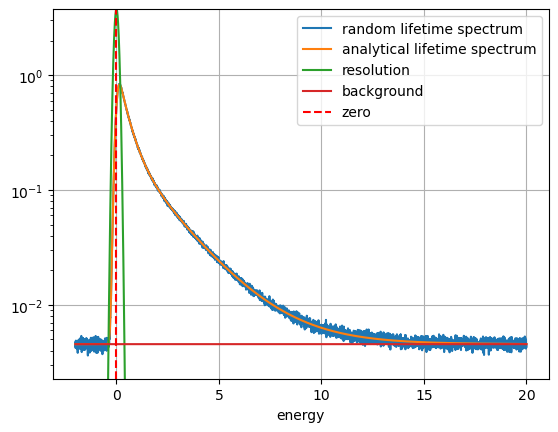

In [6]:
random_spectrum.lifetime.plot(label='random lifetime spectrum', yscale='log')
analytical_spectrum.lifetime.plot(label='analytical lifetime spectrum', yscale='log')

plt.plot(time, res_fun, label='resolution')
plt.plot(time, expected_background, label='background')
plt.axvline(0, color='red', label='zero', ls='--')
plt.legend()
plt.ylim([expected_background[0]/2, np.max([res_fun.max(), analytical_spectrum.lifetime.max()])])


plt.grid()